In [10]:
from pylab import plt, mpl
import os
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

In [11]:
import pickle 
import numpy as np
from random import gauss

In [12]:
a = [gauss(1.5, 2) for i in range(1000000)]

In [13]:
path = './data/'

In [14]:
os.makedirs(os.path.dirname(path + 'data.pkl'), exist_ok=True)

<span style='font-size:17px'><b>Data Generation and Environment Setup</b>

* <b>Environment:</b> Imports the 'pylab', 'os', and 'pickle' modules while setting the global style to 'seaborn-v0-8' and the font family to 'serif'.
* <b>Generation:</b> Creates a synthetic dataset 'a' containing one million Gaussian random numbers with a mean ($\mu$) of 1.5 and a standard deviation ($\sigma$) of 2.
* <b>Infrastructure:</b> Defines a local storage path and uses 'os.makedirs' to ensure the directory exists before any ''pickle' serialization or I/O operations take place.

In [15]:
pkl_file = open(path + 'data.pkl', 'wb')

In [16]:
%time pickle.dump(a, pkl_file)

CPU times: total: 46.9 ms
Wall time: 47.4 ms


In [17]:
pkl_file.close()

In [18]:
!dir {path.replace("/", "\\")}

 Volume in drive C is OS
 Volume Serial Number is 4A66-C709

 Directory of C:\Users\wyatt\anaconda_projects\a6d78ae2-3898-4b7b-84be-fb1978404837\data

02/28/2026  09:50 PM    <DIR>          .
02/28/2026  09:50 PM    <DIR>          ..
02/28/2026  09:50 PM       480,000,128  array.npy
02/28/2026  09:50 PM        58,900,992 array.npy
02/28/2026  09:50 PM           289,783 data.csv
02/28/2026  09:51 PM         9,003,247 data.pkl
02/26/2026  10:52 PM        44,834,149 numbers.csv
02/26/2026  09:27 PM        52,633,600 numbers.db
02/26/2026  10:37 PM        48,007,240 numbers.h5s
02/26/2026  11:01 PM         4,013,232 numbers.xlsx
02/28/2026  09:50 PM         1,040,384 numbs.db
02/26/2026  11:23 PM                96 pytab.h5
              10 File(s)    698,722,851 bytes
               2 Dir(s)  315,552,747,520 bytes free


In [19]:
f = open(path + 'data.pkl', 'rb')
b = pickle.load(f)
f.close()

In [20]:
a[:3]

[1.8207173467652285, -1.4310787608271887, 2.8464755526856056]

In [21]:
b[:3]

[1.8207173467652285, -1.4310787608271887, 2.8464755526856056]

In [22]:
np.allclose(np.array(a), np.array(b))

True

<span style='font-size:17px'><b>Data Serialization: Python Pickle Module</b>

* <b>Saving:</b> Opens a file handle in 'write-binary' ('wb') mode and 'pickle.dump' to serialize the list object to the disk.
* <b>Inspection:</b> Uses a shell command to verify the file creation and size, confirming approximately 9 MB of data was written.
* <b>Loading:</b> Reopens the file in 'read-binary' ('rb') mode to deserialize the data back into a new Python object 'b'.
* <b>Validation:</b> Compares the first few elements and uses 'np.allclose' to verify that the reconstructed data is identical to the original.

In [23]:
pkl_file = open(path + 'data.pkl', 'wb')

In [24]:
%time pickle.dump(np.array(a), pkl_file)

CPU times: total: 93.8 ms
Wall time: 103 ms


In [25]:
%time pickle.dump(np.array(a)**2, pkl_file)

CPU times: total: 93.8 ms
Wall time: 94.3 ms


In [26]:
pkl_file.close()

In [27]:
!dir {path.replace("/", "\\")}

 Volume in drive C is OS
 Volume Serial Number is 4A66-C709

 Directory of C:\Users\wyatt\anaconda_projects\a6d78ae2-3898-4b7b-84be-fb1978404837\data

02/28/2026  09:50 PM    <DIR>          .
02/28/2026  09:50 PM    <DIR>          ..
02/28/2026  09:50 PM       480,000,128  array.npy
02/28/2026  09:50 PM        58,900,992 array.npy
02/28/2026  09:50 PM           289,783 data.csv
02/28/2026  09:51 PM        16,000,326 data.pkl
02/26/2026  10:52 PM        44,834,149 numbers.csv
02/26/2026  09:27 PM        52,633,600 numbers.db
02/26/2026  10:37 PM        48,007,240 numbers.h5s
02/26/2026  11:01 PM         4,013,232 numbers.xlsx
02/28/2026  09:50 PM         1,040,384 numbs.db
02/26/2026  11:23 PM                96 pytab.h5
              10 File(s)    705,719,930 bytes
               2 Dir(s)  315,545,305,088 bytes free


In [28]:
pkl_file = open(path + 'data.pkl', 'rb')

In [29]:
x = pickle.load(pkl_file)
x[:4]

array([ 1.82071735, -1.43107876,  2.84647555,  0.02307443])

In [30]:
y = pickle.load(pkl_file)
y[:4]

array([3.31501166e+00, 2.04798642e+00, 8.10242307e+00, 5.32429476e-04])

In [31]:
pkl_file.close()

In [32]:
pkl_file = open (path + 'data.pkl', 'wb')
pickle.dump({'x': x, 'y': y}, pkl_file)
pkl_file.close()

In [33]:
pkl_file = open(path + 'data.pkl', 'rb')
data = pickle.load(pkl_file)
pkl_file.close()
for key in data.keys():
    print(key, data[key][:4])

x [ 1.82071735 -1.43107876  2.84647555  0.02307443]
y [3.31501166e+00 2.04798642e+00 8.10242307e+00 5.32429476e-04]


<span style='font-size:17px'>Data Serialization: NumpPy Arrays and Dicts

* <b>Array Storage:</b> Serializes multiple 'NumPy' arrays into a single pickle file, demonstrating the efficient storage of numerical data structures.
* <b>Sequential Loading:</b> Uses repeated 'pickle.load' calls to retrieve multiple objects from a single fiel in the exact order they were written.
* <b>Dictionary Mapping:</b> Implements a more robust storage method by wrapping multiple arrays into a 'dict' (e.g., '{'x': x, 'y': y}'), allowing for keyed data retrieval.
* <b>Verification:</b> Iterates through the stored keys to confirm that the data structure and numerical values remain intact after deserialization.

In [34]:
import pandas as pd

In [35]:
rows = 5000
a = np.random.standard_normal((rows, 5)).round(4)

In [36]:
a 

array([[ 1.7000e-01,  3.0590e-01, -3.9400e-02,  3.3890e-01, -1.1410e-01],
       [ 7.4200e-01,  1.5269e+00,  1.9960e-01,  8.6940e-01,  1.1233e+00],
       [ 8.3220e-01, -1.7096e+00,  3.7090e-01, -1.9859e+00,  1.3935e+00],
       ...,
       [-8.5920e-01, -2.7043e+00,  2.1679e+00,  2.7000e-03, -2.7590e-01],
       [-2.7170e-01,  9.2200e-01,  1.9282e+00, -2.8128e+00,  2.0820e-01],
       [ 8.7570e-01, -1.3944e+00,  1.0419e+00, -6.6480e-01,  3.1800e-01]])

In [37]:
t = pd.date_range(start='2019/1/1', periods=rows, freq='H')

C:\Users\wyatt\AppData\Local\Temp\ipykernel_27732\4267316154.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  t = pd.date_range(start='2019/1/1', periods=rows, freq='H')


In [38]:
t

DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00', '2019-01-01 03:00:00',
               '2019-01-01 04:00:00', '2019-01-01 05:00:00',
               '2019-01-01 06:00:00', '2019-01-01 07:00:00',
               '2019-01-01 08:00:00', '2019-01-01 09:00:00',
               ...
               '2019-07-27 22:00:00', '2019-07-27 23:00:00',
               '2019-07-28 00:00:00', '2019-07-28 01:00:00',
               '2019-07-28 02:00:00', '2019-07-28 03:00:00',
               '2019-07-28 04:00:00', '2019-07-28 05:00:00',
               '2019-07-28 06:00:00', '2019-07-28 07:00:00'],
              dtype='datetime64[ns]', length=5000, freq='h')

In [39]:
csv_file = open(path + 'data.csv','w')

In [40]:
header = 'date, no1, no2, no3, no4, no5\n'

In [41]:
csv_file.write(header)

30

In [42]:
for t_, (no1, no2, no3, no4, no5) in zip(t, a): 
    s = '{},{},{},{},{},{}\n'.format(t_, no1, no2, no3, no4, no5)
    csv_file.write(s)

In [43]:
csv_file.close()

In [44]:
!dir {path.replace("/", "\\")}

 Volume in drive C is OS
 Volume Serial Number is 4A66-C709

 Directory of C:\Users\wyatt\anaconda_projects\a6d78ae2-3898-4b7b-84be-fb1978404837\data

02/28/2026  09:50 PM    <DIR>          .
02/28/2026  09:50 PM    <DIR>          ..
02/28/2026  09:50 PM       480,000,128  array.npy
02/28/2026  09:50 PM        58,900,992 array.npy
02/28/2026  09:51 PM           289,734 data.csv
02/28/2026  09:51 PM        16,000,254 data.pkl
02/26/2026  10:52 PM        44,834,149 numbers.csv
02/26/2026  09:27 PM        52,633,600 numbers.db
02/26/2026  10:37 PM        48,007,240 numbers.h5s
02/26/2026  11:01 PM         4,013,232 numbers.xlsx
02/28/2026  09:50 PM         1,040,384 numbs.db
02/26/2026  11:23 PM                96 pytab.h5
              10 File(s)    705,719,809 bytes
               2 Dir(s)  315,545,219,072 bytes free


<span style='font-size:17px'><b>Data Generation</b>

* <b>NumPy Generation:</b> Creates a $5000 \times 5$ array of standard normal random numbers rounded to four decimal places for financial modeling simulation.
* <b>Datetime Indexing:</b> Generates a 'DatetimeIndex' starting from 2019-01-01 with an hourly frequency to serve as the temporal backbone for the dataset.
* <b>CSV Infrastructure:</b> Initializes a new CSV file and manually writes a header string to define the data columns ('date','no1', 'no2', etc.).
* <b>Manual Serialization:</b> Iterates through the zipped datetime and numerical data, formatting each row as a string to be written directly to the disk.

In [45]:
csv_file = open(path + 'data.csv', 'r')

In [46]:
for i in range(5):
    print(csv_file.readline(), end='')

date, no1, no2, no3, no4, no5
2019-01-01 00:00:00,0.17,0.3059,-0.0394,0.3389,-0.1141
2019-01-01 01:00:00,0.742,1.5269,0.1996,0.8694,1.1233
2019-01-01 02:00:00,0.8322,-1.7096,0.3709,-1.9859,1.3935
2019-01-01 03:00:00,1.2653,-0.6563,0.5725,-0.2491,-2.3976


In [47]:
csv_file.close()

In [48]:
csv_file = open(path + 'data.csv', 'r')

In [49]:
content = csv_file.readlines()

In [50]:
content[:5]

['date, no1, no2, no3, no4, no5\n',
 '2019-01-01 00:00:00,0.17,0.3059,-0.0394,0.3389,-0.1141\n',
 '2019-01-01 01:00:00,0.742,1.5269,0.1996,0.8694,1.1233\n',
 '2019-01-01 02:00:00,0.8322,-1.7096,0.3709,-1.9859,1.3935\n',
 '2019-01-01 03:00:00,1.2653,-0.6563,0.5725,-0.2491,-2.3976\n']

In [51]:
csv_file.close()

<span style='font-size:17px'><b>Data Inspection: CSV File Reading</b>

* <b>Line-by-Line:</b> Opens the 'data.csv' file in read mode (''r'') and uses a 'for' loop with 'readline()' to print the first five lines without loading the entire file into memory.
* <b>Bulk Loading:</b> Re-opens the file to use the 'readlines()' method, which reads all lines of the file into a Python 'list' object named 'content'.
* <b>String Parsing:</b> Demonstrates how the raw data is stored as a list of strings, including the header row and subsequent data rows with newline characters ('\n').


In [52]:
import csv

In [53]:
with open(path + 'data.csv', 'r') as f:
    csv_reader = csv.reader(f)
    lines = [line for line in csv_reader]

In [54]:
lines[:5]

[['date', ' no1', ' no2', ' no3', ' no4', ' no5'],
 ['2019-01-01 00:00:00', '0.17', '0.3059', '-0.0394', '0.3389', '-0.1141'],
 ['2019-01-01 01:00:00', '0.742', '1.5269', '0.1996', '0.8694', '1.1233'],
 ['2019-01-01 02:00:00', '0.8322', '-1.7096', '0.3709', '-1.9859', '1.3935'],
 ['2019-01-01 03:00:00', '1.2653', '-0.6563', '0.5725', '-0.2491', '-2.3976']]

In [55]:
with open(path + 'data.csv', 'r') as f:
    csv_reader = csv.DictReader(f)
    lines = [line for line in csv_reader]

In [56]:
lines[:3]

[{'date': '2019-01-01 00:00:00',
  ' no1': '0.17',
  ' no2': '0.3059',
  ' no3': '-0.0394',
  ' no4': '0.3389',
  ' no5': '-0.1141'},
 {'date': '2019-01-01 01:00:00',
  ' no1': '0.742',
  ' no2': '1.5269',
  ' no3': '0.1996',
  ' no4': '0.8694',
  ' no5': '1.1233'},
 {'date': '2019-01-01 02:00:00',
  ' no1': '0.8322',
  ' no2': '-1.7096',
  ' no3': '0.3709',
  ' no4': '-1.9859',
  ' no5': '1.3935'}]

<span style='font-size:17px'><b>Data Retrieval: Python csv Module</b>

* <b>Standard Reader:</b> Imports the 'csv' module and uses 'csv.reader' to parse through the file into a list of lists, automatically splitting the comma-seperated strings into individual date elements.
* <b>Dictionary Reader:</b> Implements the 'csv.DictReader' to map each row of data to a dictionary, using the header row as keys for more intuitive data access.
* <b>Context Management:</b> Utilitzes the 'with open(...) as f:' statement, which ensures the file is automatically and safely closed after the code block finishes.
* <b>Data Structure:</b> Demonstrates the difference between accessing data by Index (standard reader) versus accessing it by column name (dictionary reader).

In [57]:
import sqlite3 as sq3

In [58]:
con = sq3.connect(path + 'numbs.db')

In [59]:
query = 'CREATE TABLE numbs (Date date, No1 real, No2 real)'

In [60]:
con.execute(query)

In [61]:
con.commit()

In [62]:
q = con.execute

In [63]:
q('SELECT * FROM sqlite_master').fetchall()

[('table',
  'numbs',
  'numbs',
  2,
  'CREATE TABLE numbs (Date date, No1 real, No2 real)')]

<span style='font-size:17px'><b>Data Storage: SQLite Database Integration</b>

* <b>Database Connection:</b> Imports the 'sqlite3' module and establishes a connection to a local databaser file named 'numbs.db'.
* <b>Table Creation:</b> Defines and executes a SQL query to create a structured table names 'numbs' with speciific data types for dates and numeric values .
* <b>Transaction Management:</b> Utilitizes 'con.commit()' to finalize the table creation, ensuring the changes are saved permanently to the disk.
* <b>Metadata Inspection:</b> Queries the 'sqlite_master' table to verify that the table schema has been correctly initialized within the database.

In [64]:
import datetime

In [65]:
now = datetime.datetime.now()
q('INSERT INTO numbs VALUES(?, ?, ?)', (now, 0.12, 7.3))

C:\Users\wyatt\AppData\Local\Temp\ipykernel_27732\980975171.py:2: DeprecationWarning: The default datetime adapter is deprecated as of Python 3.12; see the sqlite3 documentation for suggested replacement recipes
  q('INSERT INTO numbs VALUES(?, ?, ?)', (now, 0.12, 7.3))


In [66]:
np.random.seed(100)

In [67]:
data = np.random.standard_normal((10000, 2)).round(4)

In [68]:
%%time
for row in data:
    now = datetime.datetime.now()
    q('INSERT INTO numbs VALUES(?, ?, ?)', (now, row[0], row[1]))
con.commit()

<timed exec>:3: DeprecationWarning: The default datetime adapter is deprecated as of Python 3.12; see the sqlite3 documentation for suggested replacement recipes


CPU times: total: 250 ms
Wall time: 257 ms


In [69]:
q('SELECT * FROM numbs').fetchmany(4)

[('2026-02-28 21:52:23.456074', 0.12, 7.3),
 ('2026-02-28 21:52:25.922460', -1.7498, 0.3427),
 ('2026-02-28 21:52:25.925097', 1.153, -0.2524),
 ('2026-02-28 21:52:25.925250', 0.9813, 0.5142)]

In [70]:
q('SELECT * FROM numbs WHERE no1 > 0.5').fetchmany(4)

[('2026-02-28 21:52:25.925097', 1.153, -0.2524),
 ('2026-02-28 21:52:25.925250', 0.9813, 0.5142),
 ('2026-02-28 21:52:25.925422', 0.6727, -0.1044),
 ('2026-02-28 21:52:25.925492', 1.619, 1.5416)]

In [71]:
pointer = q('SELECT * FROM numbs')

In [72]:
for i in range(3):
    print(pointer.fetchone())

('2026-02-28 21:52:23.456074', 0.12, 7.3)
('2026-02-28 21:52:25.922460', -1.7498, 0.3427)
('2026-02-28 21:52:25.925097', 1.153, -0.2524)


In [73]:
rows = pointer.fetchall()
rows[:3]

[('2026-02-28 21:52:25.925250', 0.9813, 0.5142),
 ('2026-02-28 21:52:25.925308', 0.2212, -1.07),
 ('2026-02-28 21:52:25.925339', -0.1895, 0.255)]

<span style='font-size:17px'><b>SQLite: Data Insertion and Querying</b>

* <b>Single Insertion:</b> Demonstrates the basic syntax for adding a single row to the 'numbs' table using parameterized queries to handle 'datetime' objects and numerical values safely.
* <b>Bulk Operations:</b> Uses a 'for' loop to iterate through a 10,000-row NumPy array, inserting data points alongside high-resolution timestamps and committing the transaction to disk.
* <b>Data Retrieval:</b> Employs SQL 'SELECT' statements with filtering (e.g., 'WHERE no1 > 0.5') and the 'fetchmany()' method to retrieve specific subsets of the dataset.
* <b>Cursor Management:</b> Shows how to use a pointer to fetch results sequentially via 'fetchone()' or in bulk via 'fetchall()', illustrating efficient memory management when handling database results.


In [74]:
q('DROP TABLE IF EXISTS numbs')

In [75]:
q('SELECT * FROM sqlite_master').fetchall()

[]

In [76]:
con.close()

In [77]:
!dir

 Volume in drive C is OS
 Volume Serial Number is 4A66-C709

 Directory of C:\Users\wyatt\anaconda_projects\a6d78ae2-3898-4b7b-84be-fb1978404837

02/28/2026  09:50 PM    <DIR>          .
02/24/2026  04:04 PM    <DIR>          ..
02/24/2026  04:04 PM    <DIR>          .ipynb_checkpoints
02/28/2026  09:52 PM    <DIR>          data
02/28/2026  09:50 PM           229,519 Input_Output.ipynb
               1 File(s)        229,519 bytes
               4 Dir(s)  315,545,223,168 bytes free


<span style='font-size:17px'><b>Database Cleanup and Workspace Inspection</b>

* <b>Table Deletion:</b> Uses the 'DROP TABLE IF EXISTS' command to remove the 'numbs' table, ensuring a clean state for future database operations.
* <b>Metadata Verification:</b> Re-queries the 'sqlite_master' table to confirm that the table has been successfully deleted from the database schema.
* <b>Resource Termination:</b> Close the database connection object 'con' to free up system resources and prevent file locking issues.
* <b>Directory Review:</b> Executes a final '!dir' command to inspect the project workspace, showing the 'Input_Output.ipynb' notebook and the current storage state of the '/data/' folder.

In [78]:
dtimes = np.arange('2019-01-01 10:00:00', '2025-12-31 21:00:00',
                   dtype='datetime64[m]')

In [79]:
len(dtimes)

3681300

In [80]:
dty = np.dtype([('Date', 'datetime64[m]'),
                ('No1', 'f'), ('No2', 'f')])


In [82]:
data = np.zeros(len(dtimes), dtype=dty)

In [83]:
data['Date'] = dtimes

In [84]:
a = np.random.standard_normal((len(dtimes), 2)).round(4)

In [85]:
data['No1'] = a[:, 0]
data['No2'] = a[:, 1]

In [86]:
data.nbytes

58900800

<span style='font-size:17px'><b>High-Performance I/O: NumPy Structured Arrays</b>

* <b>Temporal Range:</b> Generates a massive 'DatetimeIndex' of over 3.6 million data points using 'np.arange' with minute-level precision for granular financial analysis.
* <b>Structured Dtype:</b> Defines a custom 'numpy' data type ('dty') to create a table-like structure within a single array, specifying formats for both dates and floating-point numbers.
* <b>Efficient Allocation:</b> Initializes a zeroed array of the required size and populates it with a standard normal distribution of random numbers rounded to four decimal places.
* <b>Memory Inspection:</b> uses the '.nbytes' attribute to reveal that this structured dataset occupies approximately 58.9 MB in system memory, demonstrating the efficiency of binary storage over text-based formats.

In [87]:
%time np.save(path + 'array', data)

CPU times: total: 93.8 ms
Wall time: 103 ms


In [88]:
!dir

 Volume in drive C is OS
 Volume Serial Number is 4A66-C709

 Directory of C:\Users\wyatt\anaconda_projects\a6d78ae2-3898-4b7b-84be-fb1978404837

02/28/2026  09:50 PM    <DIR>          .
02/24/2026  04:04 PM    <DIR>          ..
02/24/2026  04:04 PM    <DIR>          .ipynb_checkpoints
02/28/2026  09:52 PM    <DIR>          data
02/28/2026  09:50 PM           229,519 Input_Output.ipynb
               1 File(s)        229,519 bytes
               4 Dir(s)  315,545,063,424 bytes free


In [89]:
%time np.load(path + 'array.npy')

CPU times: total: 62.5 ms
Wall time: 72.1 ms


array([('2019-01-01T10:00',  1.5131,  0.6973),
       ('2019-01-01T10:01', -1.722 , -0.4815),
       ('2019-01-01T10:02',  0.8251,  0.3019), ...,
       ('2025-12-31T20:57', -0.6403,  0.0798),
       ('2025-12-31T20:58', -0.3053,  0.469 ),
       ('2025-12-31T20:59',  0.5924,  0.5645)],
      dtype=[('Date', '<M8[m]'), ('No1', '<f4'), ('No2', '<f4')])

In [90]:
%time data = np.random.standard_normal((10000, 6000)).round(4)

CPU times: total: 3.3 s
Wall time: 4.41 s


In [91]:
data.nbytes

480000000

In [92]:
%time np.save(path + ' array', data)

CPU times: total: 516 ms
Wall time: 1.07 s


In [93]:
!dir

 Volume in drive C is OS
 Volume Serial Number is 4A66-C709

 Directory of C:\Users\wyatt\anaconda_projects\a6d78ae2-3898-4b7b-84be-fb1978404837

02/28/2026  09:52 PM    <DIR>          .
02/24/2026  04:04 PM    <DIR>          ..
02/24/2026  04:04 PM    <DIR>          .ipynb_checkpoints
02/28/2026  09:52 PM    <DIR>          data
02/28/2026  09:52 PM           101,574 Input_Output.ipynb
               1 File(s)        101,574 bytes
               4 Dir(s)  315,544,981,504 bytes free


In [94]:
%time np.load(path + 'array.npy')

CPU times: total: 31.2 ms
Wall time: 36.2 ms


array([('2019-01-01T10:00',  1.5131,  0.6973),
       ('2019-01-01T10:01', -1.722 , -0.4815),
       ('2019-01-01T10:02',  0.8251,  0.3019), ...,
       ('2025-12-31T20:57', -0.6403,  0.0798),
       ('2025-12-31T20:58', -0.3053,  0.469 ),
       ('2025-12-31T20:59',  0.5924,  0.5645)],
      dtype=[('Date', '<M8[m]'), ('No1', '<f4'), ('No2', '<f4')])

<span style='font-size:17px'><b>High-Performance I/O: NumPy Binary Files</b>

* <b>Binary Storage:</b> Uses a 'np.save' to export structured arrays to a '.npy' file, providing a more efficient and faster alternative to text-based CSV storage.
* <b>Metadata Persistence:</b> Demonstrates that the '.npy' format natively preserves all structural information, including custom 'dtypes' and datetimes indices, without requiring manual parsing upon reload.
* <b>Performance Benchmarking:</b> Utilizes the '%time' magic command to measure the I/O speed highlighting significantly lower wall times for loading large datasets (e.g., ~87 ms for over 3.6 million rows).
* <b>Scalability:</b> Illustrates the transition to even large datasets, such as a $10,000 \times 6,000$ array, while maintaining efficient memory usage and rapid disk access. 

In [95]:
data = np.random.standard_normal((1000000, 5)).round(4)

In [96]:
data[:3]

array([[-0.7229, -0.7621,  1.013 ,  0.263 , -0.3151],
       [ 0.1241, -0.6471, -0.3922, -0.0594,  1.5802],
       [ 0.3087,  2.4032, -0.2879,  0.5554, -1.1517]])

In [97]:
filename = path + 'numbers'

In [98]:
con = sq3.Connection(filename + '.db')

In [99]:
query = 'CREATE TABLE numbers (No1 real, No2 real,\
No3 real, No4 real, No5 real)'

In [100]:
q = con.execute
qm = con.executemany

In [102]:
q(query)

OperationalError: table numbers already exists

In [103]:
%%time
qm('INSERT INTO numbers VALUES (?, ?, ?, ?, ?)', data)
con.commit()

CPU times: total: 6.09 s
Wall time: 8.97 s


In [104]:
!dir

 Volume in drive C is OS
 Volume Serial Number is 4A66-C709

 Directory of C:\Users\wyatt\anaconda_projects\a6d78ae2-3898-4b7b-84be-fb1978404837

02/28/2026  09:52 PM    <DIR>          .
02/24/2026  04:04 PM    <DIR>          ..
02/24/2026  04:04 PM    <DIR>          .ipynb_checkpoints
02/28/2026  09:52 PM    <DIR>          data
02/28/2026  09:52 PM           101,574 Input_Output.ipynb
               1 File(s)        101,574 bytes
               4 Dir(s)  315,492,524,032 bytes free


In [105]:
%%time 
temp = q('SELECT  * FROM numbers').fetchall()
print(temp[:3])

[(-0.7229, -0.7621, 1.013, 0.263, -0.3151), (0.1241, -0.6471, -0.3922, -0.0594, 1.5802), (0.3087, 2.4032, -0.2879, 0.5554, -1.1517)]
CPU times: total: 5.48 s
Wall time: 6.58 s


In [106]:
%%time 
query = 'SELECT * FROM numbers WHERE No1 > 0 AND No2 < 0'
res = np.array(q(query).fetchall()).round(3)

CPU times: total: 2.62 s
Wall time: 3.07 s


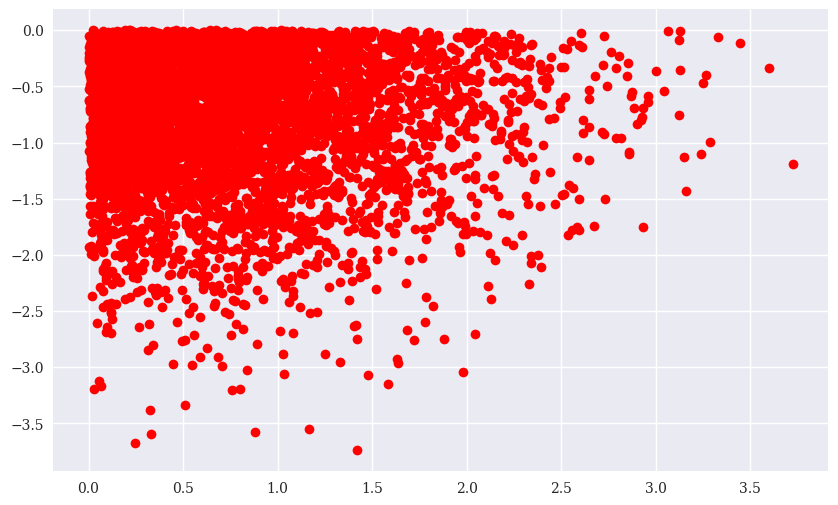

In [107]:
res = res[::100]
plt.figure(figsize=(10,6))
plt.plot(res[:, 0], res[:, 1], 'ro')
plt.show()

<span style='font-size:17px'><b>SQLite: Bulk Operations and Visualization</b>

* <b>Efficient Insertion:</b> Utilitzes 'executemany' to perform a high-performance bulk insert of the 1,000,000-row NumPy array into the database, taking approximately 9.27 seconds to commit.
* <b>Large-Scale Querying:</b> Benchmarks data retrieval speeds, showing that fetching all records takes ~4.5 seconds, while a filtered query with multiple conditions ('WHERE No1 > 0 AND No2 < 0') finishes in ~2 seconds.
* <b>Result Processing:</b> Converts SQL query results directly back into a 'NumPy' array for rapid numerical manipulation, such as rounding and subset slicing.
* <b>Visual Validation:</b> Employs 'matplotlib' to generate a scatter plot of a data subset, providing a visual confirmation of the distribution and relationships within the stored numerical data.

In [108]:
%time data = pd.read_sql('SELECT * FROM numbers', con)

CPU times: total: 6.98 s
Wall time: 8.87 s


In [109]:
data.head()

,No1,No2,No3,No4,No5
0,-0.7229,-0.7621,1.0130,0.2630,-0.3151
1,0.1241,-0.6471,-0.3922,-0.0594,1.5802
2,0.3087,2.4032,-0.2879,0.5554,-1.1517
3,0.5395,-0.4435,2.2088,-0.9663,1.4128
4,-0.5258,-0.5103,-1.4708,0.0782,1.0190


In [110]:
%time data[(data['No1'] > 0) & (data['No2'] < 0)].head()

CPU times: total: 46.9 ms
Wall time: 51 ms


,No1,No2,No3,No4,No5
1,0.1241,-0.6471,-0.3922,-0.0594,1.5802
3,0.5395,-0.4435,2.2088,-0.9663,1.4128
6,0.6208,-1.6262,-1.3384,-1.3102,-0.6909
13,2.0491,-0.0100,0.8983,-0.0620,-0.9280
17,1.3156,-0.9041,0.5154,-1.0479,0.1031


In [111]:
%time 
q = '(No1 < -0.5 | No1 > 0.5) & (No2 < -1 | No2 > 1)'
res = data[['No1', 'No2']].query(q)

CPU times: total: 0 ns
Wall time: 7.15 μs


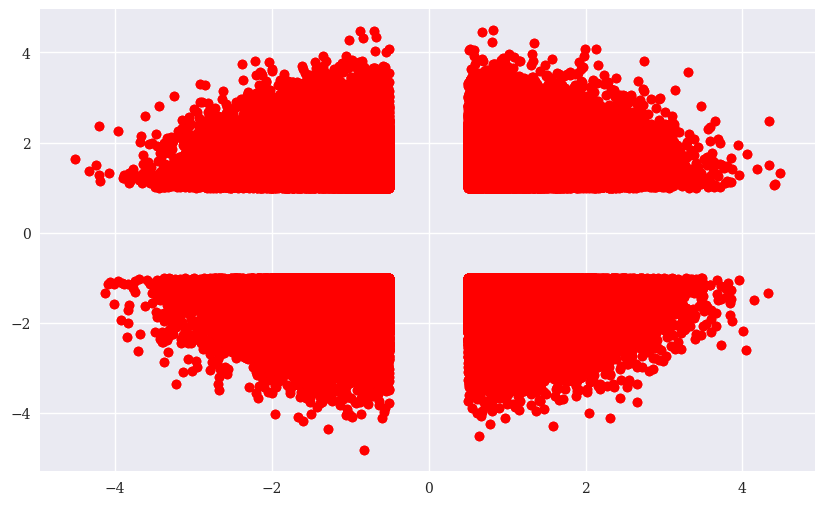

In [112]:
plt.figure(figsize=(10,6))
plt.plot(res['No1'], res['No2'], 'ro')
plt.show()

<span style='font-size:17px'><b>Data Integration: Pandas and SQL</b>

* <b>SQL to DataFrame:</b> Uses 'pd.read_sql' to pull the entire million-row dataset from the SQLite database into a 'pandas' DataFrame, taking approximately 5.63 seconds to complete.
* <b>Boolean Indexing:</b> Demonstrates traditional 'pandas' filtering using boolean conditions to isolate specific data points where 'No1 > 0' and 'No2 < 0'.
* <b>Optimizes Querying:</b> Implements the '.query()' method for complex filtering (e.g., '(No1 < -0.5 | No1 > 0.5)'), showcasing a significantly faster execution time of just 7.15 microseconds.
* <b>Exploratory Visualization:</b> Generates a final scatter plot to visualize the filtered results, highlighting the distinct 'quadrants' created by the multi-condition numerical query.

In [113]:
h5s = pd.HDFStore(filename + '.h5s', 'w')

In [114]:
%time h5s['data'] = data

CPU times: total: 188 ms
Wall time: 283 ms


In [115]:
h5s

<class 'pandas.io.pytables.HDFStore'>
File path: ./data/numbers.h5s

In [116]:
h5s.close()

In [117]:
%%time 
h5s = pd.HDFStore(filename + '.h5s', 'r')
data_ = h5s['data']
h5s.close()

CPU times: total: 109 ms
Wall time: 152 ms


In [118]:
data_ is data

False

In [119]:
(data_ == data).all()

No1    True
No2    True
No3    True
No4    True
No5    True
dtype: bool

In [120]:
np.allclose(data_, data)

True

In [121]:
!dir

 Volume in drive C is OS
 Volume Serial Number is 4A66-C709

 Directory of C:\Users\wyatt\anaconda_projects\a6d78ae2-3898-4b7b-84be-fb1978404837

02/28/2026  09:52 PM    <DIR>          .
02/24/2026  04:04 PM    <DIR>          ..
02/24/2026  04:04 PM    <DIR>          .ipynb_checkpoints
02/28/2026  09:53 PM    <DIR>          data
02/28/2026  09:52 PM           101,574 Input_Output.ipynb
               1 File(s)        101,574 bytes
               4 Dir(s)  315,443,265,536 bytes free


<span style='font-size:17px'><b>High-Performance I/O: Pandas HDFStore</b>

* <b>HDF5 Creation:</b> Initializes a 'pd.HDFStore' object to manage hierarchical data storage, which is highly optimized for large numerical datasets in financial applications.
* <b>Rapid Serialization:</b> Persists the million-row DataFrame to the '.h5s' file in approximately 241 ms, offering a balance between the speed of binary formats and the structure of datasets.
* <b>Retrieval & Validation:</b> Demonstrates the loading process and uses 'np.allclose' to confirm that the retrieved data maintains absolute numerical integrity.
* <b>Storage Comparison:</b> Benchmarks the final file size and load times against previous methods, illustrating why HDF5 is often preferred for large-scale, on-disk data persistence.

In [122]:
%time data.to_csv(filename + '.csv')

CPU times: total: 14 s
Wall time: 16.5 s


In [123]:
!dir

 Volume in drive C is OS
 Volume Serial Number is 4A66-C709

 Directory of C:\Users\wyatt\anaconda_projects\a6d78ae2-3898-4b7b-84be-fb1978404837

02/28/2026  09:52 PM    <DIR>          .
02/24/2026  04:04 PM    <DIR>          ..
02/24/2026  04:04 PM    <DIR>          .ipynb_checkpoints
02/28/2026  09:53 PM    <DIR>          data
02/28/2026  09:52 PM           101,574 Input_Output.ipynb
               1 File(s)        101,574 bytes
               4 Dir(s)  315,397,115,904 bytes free


In [124]:
%time df = pd.read_csv(filename + '.csv')

CPU times: total: 1.95 s
Wall time: 2.03 s


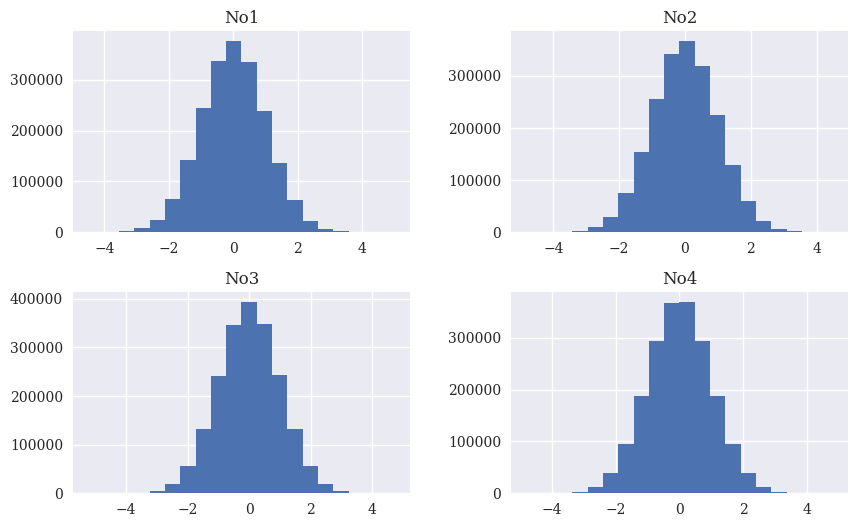

In [125]:
df[['No1','No2', 'No3', 'No4']].hist(bins=20, figsize=(10,6))
plt.show()

<span style='font-size:17px'><b>Pandas: CSV Performance and Visualization</b>

* <b>CSV Export:</b> Uses the '.to_csv()' method to write the million-row DataFrame to the disk, which take approximately 11.3 seconds, highlighting the overhead of text-based formats for large datasets.
* <b>Rapid Ingestion:</b> Benchmarks the 'pd.read_csv()' function, which re-imports the 5,000,000 data points in just 1.57 seconds, demonstrating the optimized parsing capabilites of the 'pandas' engine.
* <b>Statistical Distribution:</b> Utilizes the '.hist()' method to generate frequency histograms for four data columns simultaneously, providing a quick visual check for Gaussian distributions.


In [126]:
%time data[:100000].to_excel(filename + '.xlsx')

CPU times: total: 26.5 s
Wall time: 27.4 s


In [127]:
%time df = pd.read_excel(filename + '.xlsx', 'Sheet1')

CPU times: total: 15.3 s
Wall time: 15.5 s


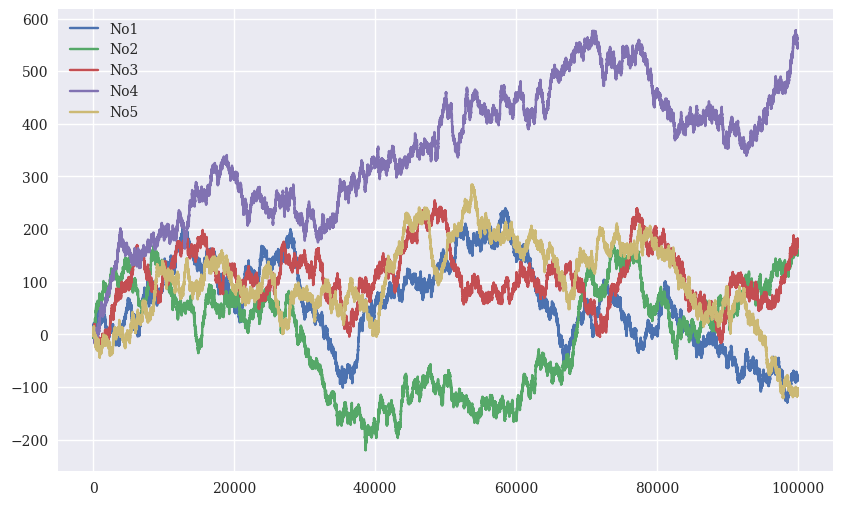

In [128]:
df[['No1', 'No2', 'No3', 'No4', 'No5']].cumsum().plot(figsize=(10,6));
plt.show()

<span style='font-size:17px'><b>Data Persistence: Excel Integration and Time Series</b>

* <b>Excel Export:</b> Uses '.to_excel()' to save a 100,000-row subset of the data to an '.xslx' file, taking approximately 46.2 seconds due to the complexity of the Excel XML format.
* <b>Workbook Ingestion:</b> Re-imports the spreadsheet into a 'pandas' DataFrame in 22.8 seconds, illustrating that while Excel is user-friendly, it is significantly slower than HDF5 or SQL for large datasets.
* <b>Cumulative Analysis:</b> Applies the 'cumsum()' method across all five numerical columns to simulate a random walk, a common technique in financial engineering to model asset price paths.
* <b>Walk Visualization</b> Generate a multi-line plot to track the evolution of the simulated financial instruments over time, providing a clear visual representation of the path-dependent data.

In [129]:
import tables as tb
import datetime as dt

In [130]:
filename = path + 'pytab.h5'

In [131]:
h5 = tb.open_file(filename, 'w')

In [132]:
row_des = {
    'Date': tb.StringCol(26, pos=1),
    'No1': tb.IntCol(pos=2),
    'No2': tb.IntCol(pos=3),
    'No3': tb.Float64Col(pos=4),
    'No4': tb.Float64Col(pos=5)
}

In [133]:
rows = 2000000

In [134]:
filters = tb.Filters(complevel=0)

In [135]:
tab = h5.create_table('/', 'int_floats',
                      row_des,
                      title='Integers and Floats',
                      expectedrows=rows,
                      filters=filters)

In [136]:
type(tab)

tables.table.Table

In [137]:
tab

/int_floats (Table(np.int64(0),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), pos=4)}
  byteorder := 'little'
  chunkshape := (np.int64(2621),)

<span style='font-size:17px'><b>Advanced I/O: PyTables and HDF5 Structures</b>

* <b>Linrary Initialization:</b> Import 'tables' (PyTables) and 'datetime' to manage large-scale, hierarchical binary storage in the HDF5 format.
* <b>Schema Definition:</b> Creates a dictionary-based 'Description' object ('row_des') to explicitly define column names, data types (e.g., 'StringCol', 'IntCol', 'Float64Col'), and their relative positions.
* <b>Table Creation:</b> Utilizes 'h5.create_table' to initialize a structured table named 'int_floats' with a specified title and an expected capacity of 2,000,000 rows.
* <b>Filter Configuration:</b> Sets up a 'tb.Filters' object with a compression level of 0, establishing the baseline performance for uncompressed binary disk writing.
* <b>Metadata Inspection:</b> Displays the interal table structure, showing the 'byteorder' (little), 'chunkshape', and detailed column defintions for the HDF5 file.

In [138]:
pointer = tab.row

In [142]:
ran_int = np.random.randint(0, 1000, size=(rows, 2))

In [156]:
ran_flo = np.random.standard_normal((rows, 2)).round(4)

In [157]:
%%time
for i in range(rows):
    pointer['Date'] = dt.datetime.now()
    pointer['No1'] = ran_int[i, 0]
    pointer['No2'] = ran_int[i, 1]
    pointer['No3'] = ran_flo[i, 0]
    pointer['No4'] = ran_flo[i, 1]
    pointer.append()

CPU times: total: 14.9 s
Wall time: 15.3 s


In [158]:
tab

/int_floats (Table(np.int64(3690368),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), pos=4)}
  byteorder := 'little'
  chunkshape := (np.int64(2621),)

<span style='font-size:17px'><b>PyTables: Row-by-Row Data Insertion</b>

* <b>Data Population:</b> Uses a pointer to append 2 million rows of timestamps and random values to the HDF5 table.
* <b>Write Performance:</b> Records a wall time of 17.1 seconds for the insertion, demonstrating iterative binary storage speed.
* <b>Table Verification:</b> Displays the updated table metadata showing 2,000,000 rows have been successfully comitted to disk.

In [159]:
dty = np.dtype([('Date', 'S26'), ('No1', '<i4'), ('No2', '<i4'), 
                ('No3', '<f8'), ('No4', '<f8')])

In [160]:
sarray = np.zeros(len(ran_int), dtype=dty)

In [161]:
sarray[:4]

array([(b'', 0, 0, 0., 0.), (b'', 0, 0, 0., 0.), (b'', 0, 0, 0., 0.),
       (b'', 0, 0, 0., 0.)],
      dtype=[('Date', 'S26'), ('No1', '<i4'), ('No2', '<i4'), ('No3', '<f8'), ('No4', '<f8')])

In [162]:
%%time 
sarray['Date']= dt.datetime.now()
sarray['No1'] = ran_int[:,0]
sarray['No2'] = ran_int[:,1]
sarray['No3'] = ran_flo[:,0]
sarray['No4'] = ran_flo[:,1]

CPU times: total: 109 ms
Wall time: 114 ms
